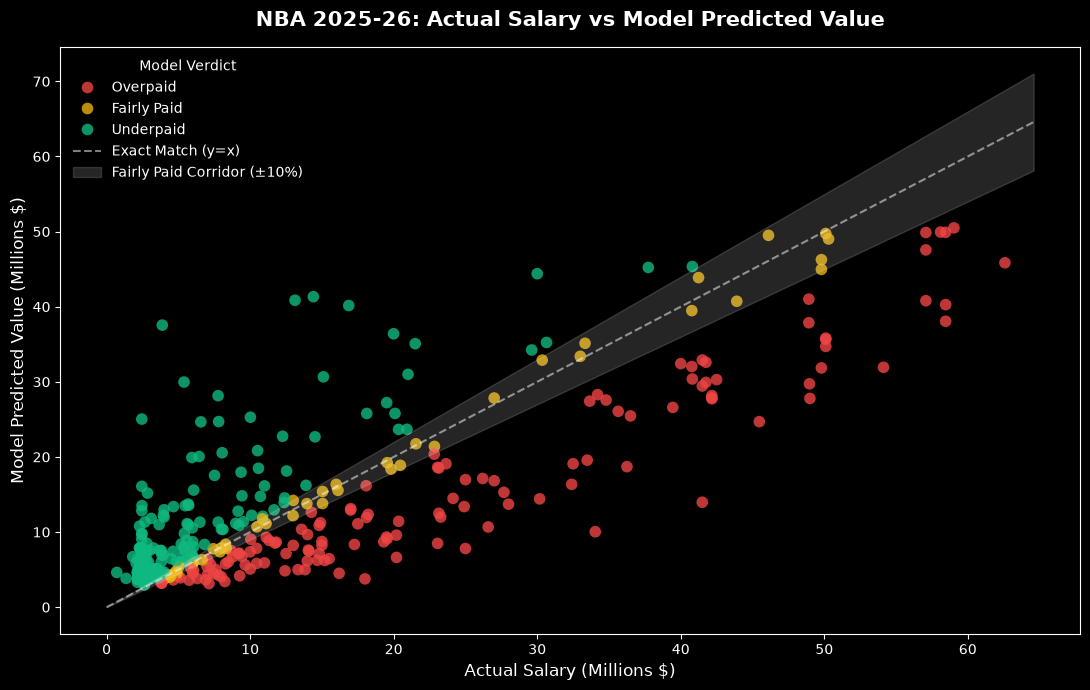

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Veriyi oku
with open('../web/data/predictions.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['ACTUAL_M'] = df['ACTUAL_SALARY'] / 1e6
df['PREDICTED_M'] = df['PREDICTED_SALARY'] / 1e6
df['DIFF_M'] = df['DIFFERENCE'] / 1e6

# Grafikte göstermek için Fairly Paid (±%10) hesabı yap
margin = df['ACTUAL_SALARY'] * 0.10
is_fair = df['DIFFERENCE'].abs() < margin

# Grafik için geçici bir STATUS sütunu oluştur (Orijinal JSON'u bozmaz)
df['PLOT_STATUS'] = df['STATUS']
df.loc[is_fair, 'PLOT_STATUS'] = 'Fairly Paid'

# Grafik ayarları (Karanlık tema)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11, 7))

# Renk paleti (Fairly Paid için Sarı tonu eklendi)
custom_palette = {
    'Overpaid': '#ef4444',     # Kırmızı
    'Underpaid': '#10b981',    # Yeşil
    'Fairly Paid': '#eab308'   # Sarı/Turuncu
}

# Dağılım (Scatter) Grafiği
sns.scatterplot(
    data=df, 
    x='ACTUAL_M', 
    y='PREDICTED_M', 
    hue='PLOT_STATUS',
    palette=custom_palette,
    alpha=0.8,
    s=70,
    edgecolor='none',
    ax=ax
)

# Y = X Çizgisi ve FAIRLY PAID KORİDORU (%10 Hata Payı)
max_val = max(df['ACTUAL_M'].max(), df['PREDICTED_M'].max()) + 2
x_vals = np.linspace(0, max_val, 100)
y_vals = x_vals

# Ana tam eşleşme çizgisi
ax.plot(x_vals, y_vals, color='white', linestyle='--', alpha=0.5, label='Exact Match (y=x)')

# %10 Alt ve Üst Sınır (Gölgeli Alan)
y_upper = x_vals * 1.10
y_lower = x_vals * 0.90
ax.fill_between(x_vals, y_lower, y_upper, color='white', alpha=0.15, label='Fairly Paid Corridor (±10%)')

# Etiketler ve Başlık
ax.set_title('NBA 2025-26: Actual Salary vs Model Predicted Value', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Actual Salary (Millions $)', fontsize=12)
ax.set_ylabel('Model Predicted Value (Millions $)', fontsize=12)
ax.legend(title='Model Verdict', frameon=False)

plt.tight_layout()
plt.show()


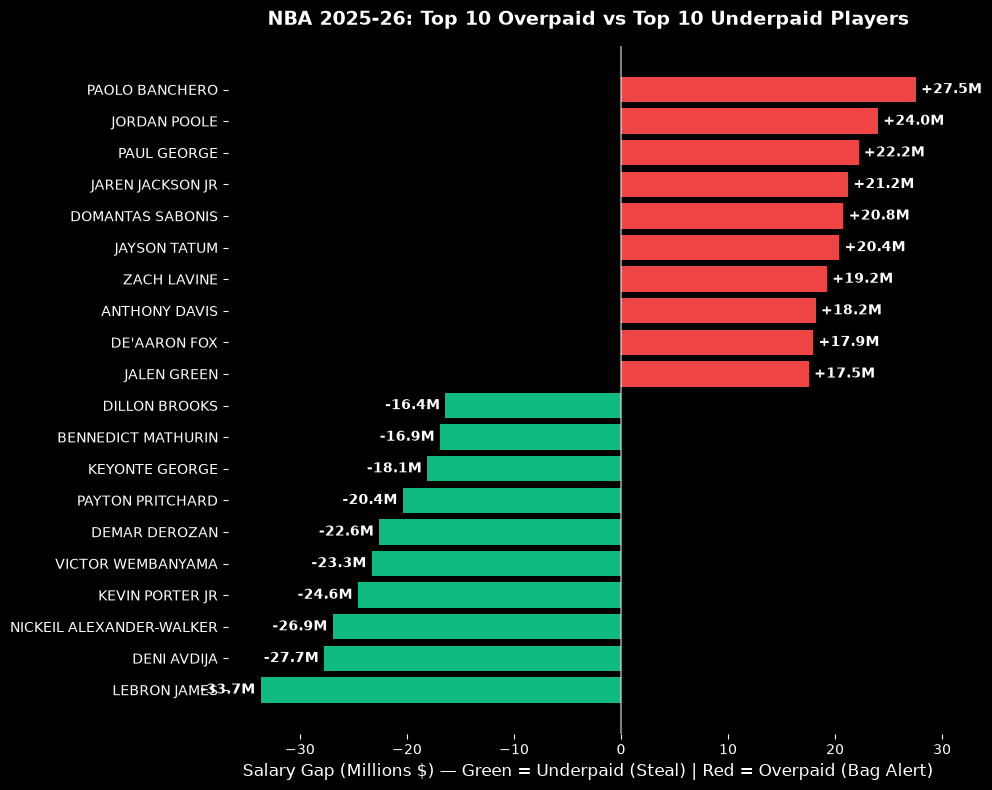

In [3]:
# En çok Overpaid ve Underpaid olan 10 oyuncu
top_overpaid = df.nlargest(10, 'DIFFERENCE')
top_underpaid = df.nsmallest(10, 'DIFFERENCE')
top_df = pd.concat([top_overpaid, top_underpaid]).sort_values('DIFF_M')

# Renkleri belirle (Underpaid için yeşil, Overpaid için kırmızı)
colors = ['#10b981' if x < 0 else '#ef4444' for x in top_df['DIFF_M']]

fig, ax = plt.subplots(figsize=(10, 8))

# Yatay bar plot
bars = ax.barh(top_df['PLAYER_NAME'], top_df['DIFF_M'], color=colors)

ax.set_title('NBA 2025-26: Top 10 Overpaid vs Top 10 Underpaid Players', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Salary Gap (Millions $) — Green = Underpaid (Steal) | Red = Overpaid (Bag Alert)', fontsize=12)

# Barların yanına değerleri yazdır
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.5 if width > 0 else width - 0.5
    ha = 'left' if width > 0 else 'right'
    ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f"{'+' if width>0 else ''}{width:.1f}M", 
            ha=ha, va='center', color='white', fontweight='bold', fontsize=10)

# Sıfır çizgisini belirginleştir
ax.axvline(0, color='white', linewidth=1.5, alpha=0.5)

# Kenarlıkları temizle
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()
